In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
ruta_archivo ='https://raw.githubusercontent.com/KatiaMusun/parcial4-Katia-Musun-2524562022/refs/heads/main/archivos/clave_F_agrupacion.csv'
df=pd.read_csv(ruta_archivo)
df.head()

,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,F-R0218,47,1028,5.48,63.75,3.04,5,13
1,F-R0008,35,733,1.41,25.26,5.60,3,3
2,F-R0082,36,985,9.98,98.95,7.11,3,27
3,F-R0009,30,473,1.61,5.00,5.76,12,1
4,F-R0244,39,978,2.57,27.35,3.31,4,10


In [ ]:
print(df.shape)

(250, 8)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   registro_id       250 non-null    object 
 1   edad              250 non-null    int64  
 2   ingresos          250 non-null    int64  
 3   frecuencia_uso    250 non-null    float64
 4   gasto_promedio    250 non-null    float64
 5   satisfaccion      249 non-null    float64
 6   reclamos          250 non-null    int64  
 7   antiguedad_meses  250 non-null    int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 15.8+ KB
None


valores nulos

In [ ]:
print(df.isnull().sum())

registro_id         0
edad                0
ingresos            0
frecuencia_uso      0
gasto_promedio      0
satisfaccion        1
reclamos            0
antiguedad_meses    0
dtype: int64


se eliminaron las variable de tipo null

In [ ]:
df = df.dropna()

print(df.isnull().sum())

registro_id         0
edad                0
ingresos            0
frecuencia_uso      0
gasto_promedio      0
satisfaccion        0
reclamos            0
antiguedad_meses    0
dtype: int64


valores dublicados

In [ ]:
print(df.duplicated().sum())

0


no se encontraron dublicados

descripcion basica

In [ ]:
print(df.describe())

             edad     ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
count  249.000000   249.000000      249.000000      249.000000    249.000000   
mean    39.317269  1066.473896        5.456546       84.868635      6.872209   
std      9.969699   428.300844        3.042641       49.406907      1.950381   
min     18.000000   300.000000        0.000000        5.000000      2.280000   
25%     32.000000   748.000000        2.750000       46.720000      5.180000   
50%     39.000000   985.000000        5.480000       72.590000      7.280000   
75%     47.000000  1344.000000        7.840000      120.290000      8.480000   
max     66.000000  2900.000000       13.360000      260.000000     10.000000   

         reclamos  antiguedad_meses  
count  249.000000        249.000000  
mean     2.405622         18.365462  
std      1.989926         13.092066  
min      0.000000          1.000000  
25%      1.000000          9.000000  
50%      2.000000         16.000000  
75%      4.00

Normalizar o escalar los datos correctamente.

In [ ]:
from sklearn.preprocessing import StandardScaler


variables = [
    'edad',
    'ingresos',
    'frecuencia_uso',
    'gasto_promedio',
    'satisfaccion',
    'reclamos',

]


X = df[variables]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Aplicar el método del codo o una técnica para seleccionar el número de grupos

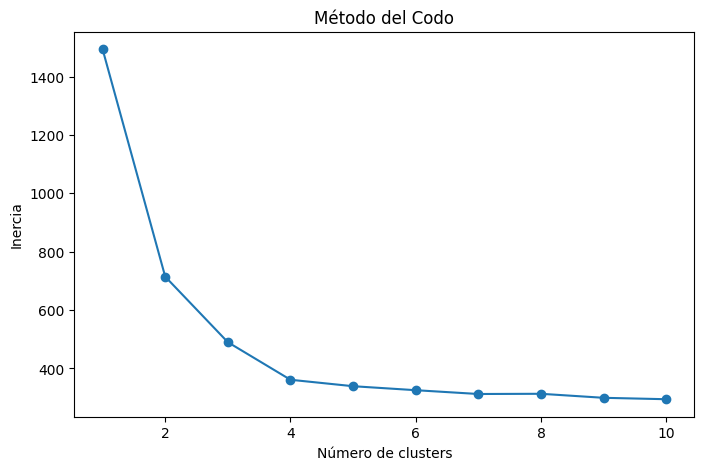

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercia = []

for k in range(1, 11):
    modelo = KMeans(n_clusters=k, random_state=42)
    modelo.fit(X_scaled)
    inercia.append(modelo.inertia_)

# Graficar
plt.figure(figsize=(8,5))
plt.plot(range(1,11), inercia, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

Aplicación de K-Means

In [ ]:
# Aplicar K-Means
kmeans = KMeans(n_clusters=3, random_state=42)

# Crear clusters
df['cluster'] = kmeans.fit_predict(X_scaled)

# Mostrar resultados
df.head()

,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses,cluster
0,F-R0218,47,1028,5.48,63.75,3.04,5,13,0
1,F-R0008,35,733,1.41,25.26,5.60,3,3,0
2,F-R0082,36,985,9.98,98.95,7.11,3,27,2
3,F-R0009,30,473,1.61,5.00,5.76,12,1,0
4,F-R0244,39,978,2.57,27.35,3.31,4,10,0


In [ ]:
from sklearn.cluster import KMeans

# Crear modelo
kmeans = KMeans(n_clusters=3, random_state=42)

# Entrenar modelo y crear clusters
df['cluster'] = kmeans.fit_predict(X_scaled)

# Mostrar primeras filas
display(df.head())

,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses,cluster
0,F-R0218,47,1028,5.48,63.75,3.04,5,13,0
1,F-R0008,35,733,1.41,25.26,5.60,3,3,0
2,F-R0082,36,985,9.98,98.95,7.11,3,27,2
3,F-R0009,30,473,1.61,5.00,5.76,12,1,0
4,F-R0244,39,978,2.57,27.35,3.31,4,10,0


Visualización de grupos

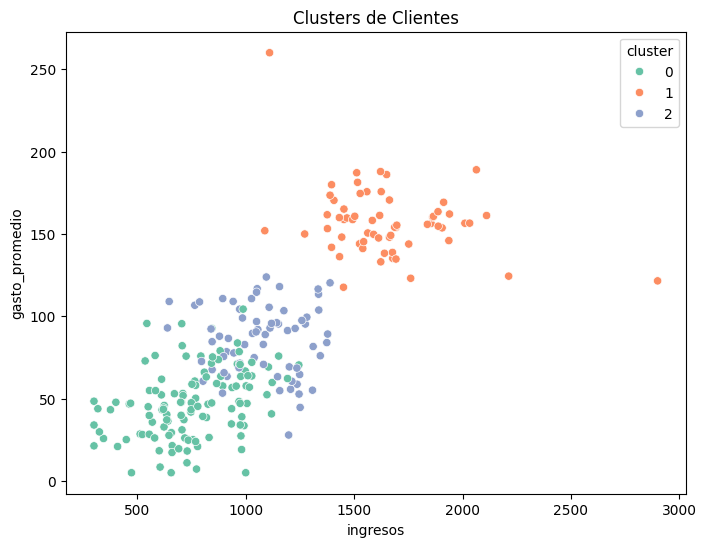

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='ingresos',
    y='gasto_promedio',
    hue='cluster',
    palette='Set2'
)

plt.title('Clusters de Clientes')
plt.show()